# Superstore Sales Dataset
##  Business Objective

The objective of this project is to analyze sales performance across products, customers, categories, regions, and shipping methods.

The analysis aims to identify the key drivers of revenue, discover high-performing and underperforming business areas, and provide data-driven recommendations that can help improve sales performance and business growth.

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import statsmodels.api as sm
import scipy.stats as stats

# Load the Dataset

In [71]:
df=pd.read_csv('train.csv')

# Data Understanding

In [72]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.00",South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.00",South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,"90,036.00",West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.00",South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.00",South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [74]:
df.shape

(9800, 18)

In [75]:
df.describe()

,Row ID,Postal Code,Sales
count,"9,800.00","9,789.00","9,800.00"
mean,"4,900.50","55,273.32",230.77
std,"2,829.16","32,041.22",626.65
min,1.00,"1,040.00",0.44
25%,"2,450.75","23,223.00",17.25
50%,"4,900.50","58,103.00",54.49
75%,"7,350.25","90,008.00",210.61
max,"9,800.00","99,301.00","22,638.48"


#  Data Cleaning Process

In [76]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [77]:
df=df.dropna(subset=['Postal Code'])

In [78]:
df.shape

(9789, 18)

df.isnull().sum()


In [79]:
df.duplicated().sum()

np.int64(0)

In [80]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [81]:
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9789 non-null   int64         
 1   Order ID       9789 non-null   object        
 2   Order Date     9789 non-null   datetime64[ns]
 3   Ship Date      9789 non-null   datetime64[ns]
 4   Ship Mode      9789 non-null   object        
 5   Customer ID    9789 non-null   object        
 6   Customer Name  9789 non-null   object        
 7   Segment        9789 non-null   object        
 8   Country        9789 non-null   object        
 9   City           9789 non-null   object        
 10  State          9789 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9789 non-null   object        
 13  Product ID     9789 non-null   object        
 14  Category       9789 non-null   object        
 15  Sub-Category   9789 non-nu

## Data Cleaning
1. Checked for missing values
2. Removed rows containing missing values in the Postal Code column.
3. Checked duplicate records
4. Made the dates have dateform

# Business Questions

## What is the total sales generated?

In [83]:
total_sales = df['Sales'].sum()
print('The total sales are',total_sales)

The total sales are 2252607.4127


## Which product categories generate the highest sales?

In [84]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales

Category
Technology        825,856.11
Furniture         723,538.48
Office Supplies   703,212.82
Name: Sales, dtype: float64

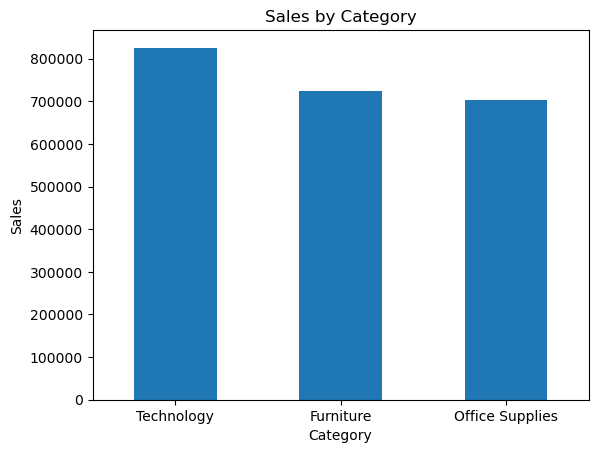

In [85]:
plt.figure()
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

**The three categories are surprisingly balanced. Technology leads at ~$820K but the difference from Office Supplies (~$705K) is only about 16% — not a dramatic gap.**

## Which sub-categories generate the highest sales?

In [86]:
sub_category_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
sub_category_sales

Sub-Category
Phones        326,487.70
Chairs        322,107.53
Storage       217,779.10
Tables        202,810.63
Binders       200,028.79
Machines      189,238.63
Accessories   163,881.69
Copiers       146,248.09
Bookcases     109,408.30
Appliances    104,075.46
Furnishings    89,212.02
Paper          76,736.10
Supplies       46,420.31
Art            26,697.37
Envelopes      16,126.01
Labels         12,347.73
Fasteners       3,001.96
Name: Sales, dtype: float64

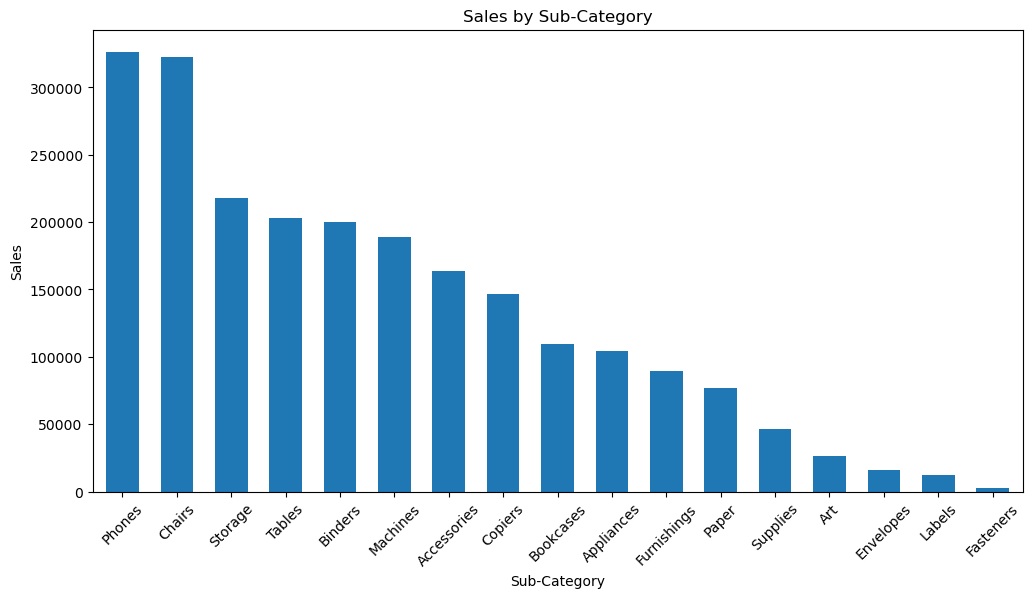

In [87]:
plt.figure(figsize=(12,6))
sub_category_sales.plot(kind='bar',width=0.6) 
plt.title('Sales by Sub-Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

**1 — Phones and Chairs dominate by far
The top 2 sub-categories are almost equal (~$330K vs ~$325K) and are significantly ahead of everything else. Together they represent nearly 30% of total sales.**

**2 — Clear drop-off after the top 6
Phones, Chairs, Storage, Tables, Binders and Machines form a clear "top tier". After Machines (~$190K) there is a noticeable step down to Accessories (~$165K) and below.**

**3 — Bottom 5 are almost irrelevant in sales
Art, Envelopes, Labels and Fasteners generate almost nothing — Fasteners is barely visible on the chart at ~$3,000.**

## Which regions generate the highest revenue?

In [88]:
sales_per_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sales_per_region

Region
West      710,219.68
East      660,589.36
Central   492,646.91
South     389,151.46
Name: Sales, dtype: float64

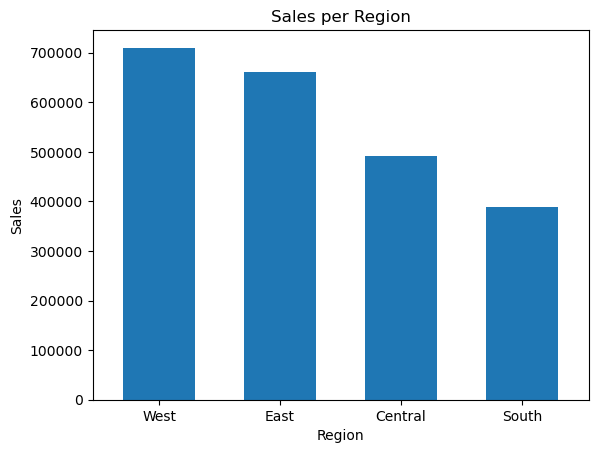

In [89]:
plt.figure()
sales_per_region.plot(kind='bar',width=0.6) 
plt.title('Sales per Region')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

**1 — West and East are the strong regions
Together they account for roughly 60% of total sales. They are close to each other (~$50K difference) suggesting similar market strength.**

**2 — Central and South are significantly behind
Central is ~30% below West, and South is ~45% below West. These are underperforming regions with clear growth potential.**

**3 — The gap between top and bottom is large
West generates nearly double the sales of South (~$710K vs ~$390K) — that is a significant regional imbalance.**

## Which states generate the highest sales?

In [90]:
sales_per_state = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
sales_per_state

State
California             446,306.46
New York               306,361.15
Texas                  168,572.53
Washington             135,206.85
Pennsylvania           116,276.65
Florida                 88,436.53
Illinois                79,236.52
Michigan                76,136.07
Ohio                    75,130.35
Virginia                70,636.72
North Carolina          55,165.96
Indiana                 48,718.40
Georgia                 48,219.11
Kentucky                36,458.39
Arizona                 35,272.66
New Jersey              34,610.97
Colorado                31,841.60
Wisconsin               31,173.43
Tennessee               30,661.87
Minnesota               29,863.15
Massachusetts           28,634.43
Delaware                27,323.00
Maryland                23,705.52
Rhode Island            22,525.03
Missouri                22,205.15
Oklahoma                19,683.39
Alabama                 19,510.64
Oregon                  17,284.46
Nevada                  16,729.10
Connecti

In [91]:
sales_per_state.head(10)#Because there are too much to be seen in a barplot

State
California     446,306.46
New York       306,361.15
Texas          168,572.53
Washington     135,206.85
Pennsylvania   116,276.65
Florida         88,436.53
Illinois        79,236.52
Michigan        76,136.07
Ohio            75,130.35
Virginia        70,636.72
Name: Sales, dtype: float64

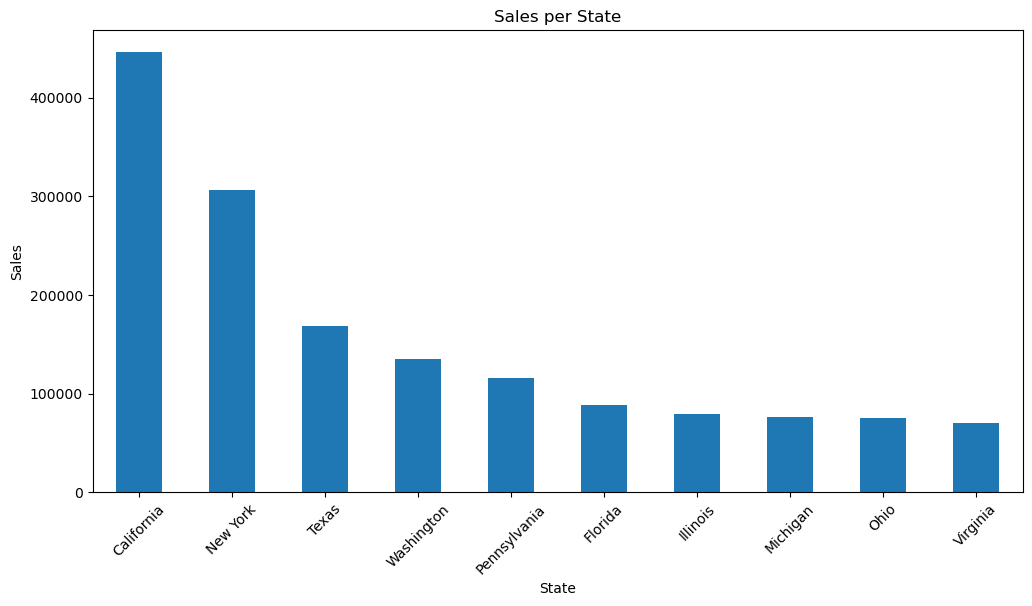

In [92]:
plt.figure(figsize=(12,6))
sales_per_state.head(10).plot(kind='bar',width=0.5) 
plt.title('Sales per State')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

**1 — California dominates massively
California alone generates ~$445K — nearly 50% more than New York (second place) and almost 3x more than Texas (third). It is the single most important market by far.**

**2 — Clear three-tier structure
Tier 1: California, New York — far ahead of everyone
Tier 2: Texas, Washington, Pennsylvania — mid range
Tier 3: Florida, Illinois, Michigan, Ohio, Virginia — all similar and much lower**

**3 — The bottom 6 states are very close to each other
From Florida to Virginia the difference is tiny — they are all performing at roughly the same level (70K–90K).**

**This connects directly to the previous chart:
California and New York explain why West and East are the top regions — they are the powerhouse states driving those regions.**

## Which customers generate the most sales

In [93]:
customer_sales= df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)
customer_sales

Customer Name
Sean Miller       25,043.05
Tamara Chand      19,052.22
Raymond Buch      15,117.34
Tom Ashbrook      14,595.62
Adrian Barton     14,473.57
                     ...   
Mitch Gastineau       16.74
Carl Jackson          16.52
Sung Chung            14.11
Lela Donovan           5.30
Thais Sissman          4.83
Name: Sales, Length: 793, dtype: float64

In [94]:
top_customers=customer_sales.head(15)
top_customers

Customer Name
Sean Miller          25,043.05
Tamara Chand         19,052.22
Raymond Buch         15,117.34
Tom Ashbrook         14,595.62
Adrian Barton        14,473.57
Ken Lonsdale         14,175.23
Sanjit Chand         14,142.33
Hunter Lopez         12,873.30
Sanjit Engle         12,209.44
Christopher Conant   12,129.07
Todd Sumrall         11,891.75
Greg Tran            11,820.12
Becky Martin         11,789.63
Seth Vernon          11,470.95
Caroline Jumper      11,164.97
Name: Sales, dtype: float64

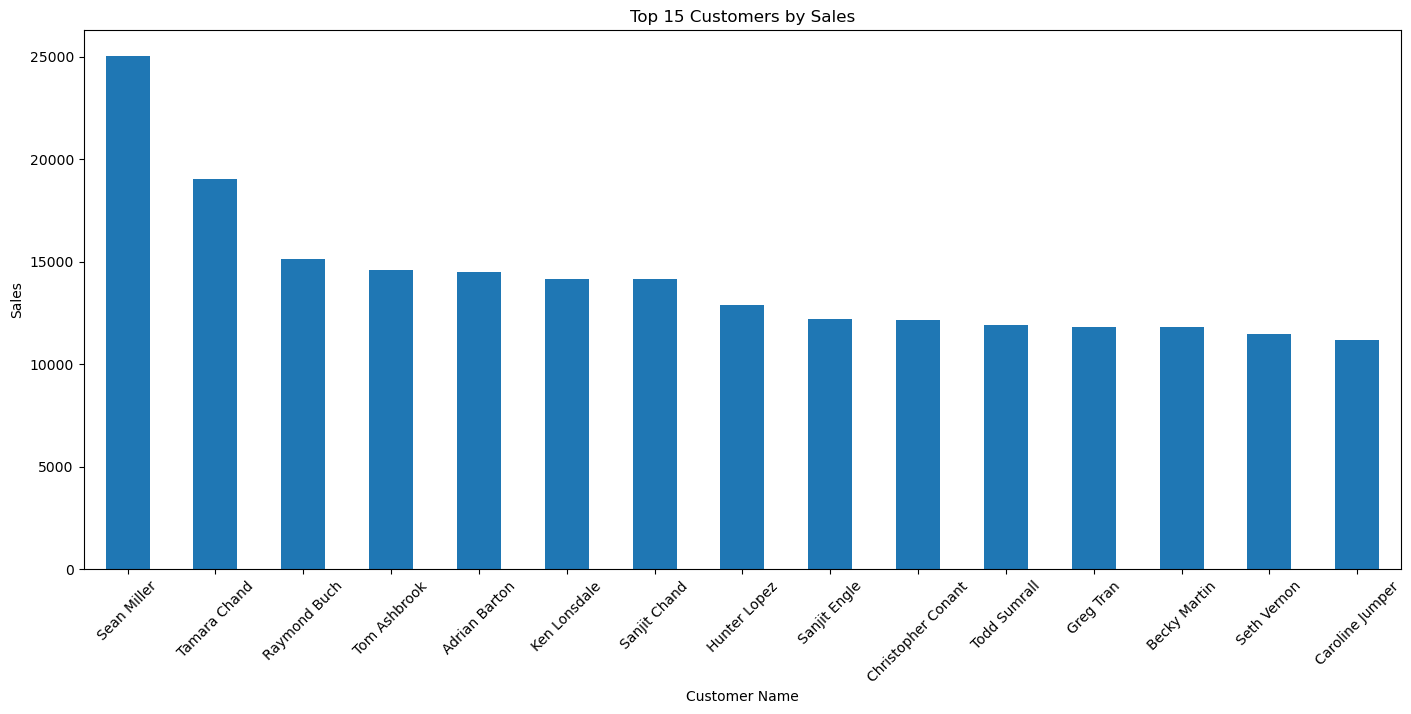

In [95]:
plt.figure(figsize=(17,7))
top_customers.plot(kind='bar',width=0.5) 
plt.title('Top 15 Customers by Sales')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

**1 — Sean Miller stands out clearly
At 25,000 he is 32% ahead of second place (Tamara Chand at 19,000) — a significant gap for individual customers.**

**2 — After the top 2 the rest are very close
From Raymond Buch (15,000) to Caroline Jumper (11,000) the difference is only  4,000 across 13 customers — they form a very tight group.**

## Which shipping mode is used most frequently?

In [96]:
df['Ship Mode'].value_counts()

Ship Mode
Standard Class    5849
Second Class      1901
First Class       1501
Same Day           538
Name: count, dtype: int64

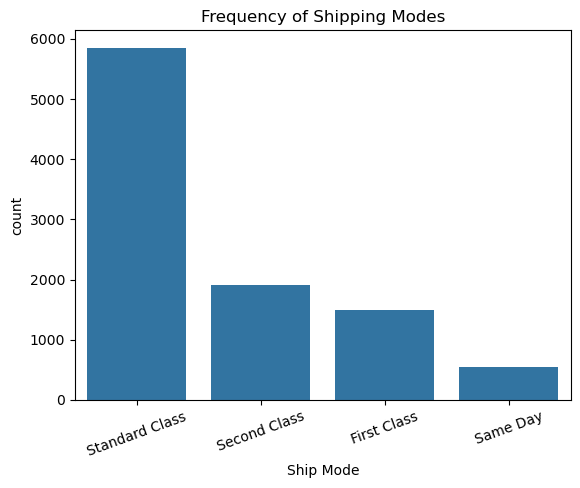

In [97]:
plt.figure()
sns.countplot(x=df['Ship Mode'],order=df['Ship Mode'].value_counts().index)
plt.title('Frequency of Shipping Modes')
plt.xticks(rotation=20)
plt.show()

**1 — Standard Class dominates completely
~60% of all orders use Standard Class — it is by far the most popular shipping method. Customers clearly prioritize cost over speed.**

**2 — Same Day is barely used
Only ~550 orders use Same Day delivery — less than 6% of total. This makes sense as it is the most expensive option.**

**3 — Clear preference hierarchy
Cheaper/slower → more popular. The order perfectly follows cost: Standard < Second < First < Same Day.**

##  Which shipping mode generates the highest sales?

In [98]:
sales_per_shipping_mode=df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)
pd.options.display.float_format = '{:,.2f}'.format
sales_per_shipping_mode

Ship Mode
Standard Class   1,332,617.14
Second Class       449,198.98
First Class        345,572.26
Same Day           125,219.04
Name: Sales, dtype: float64

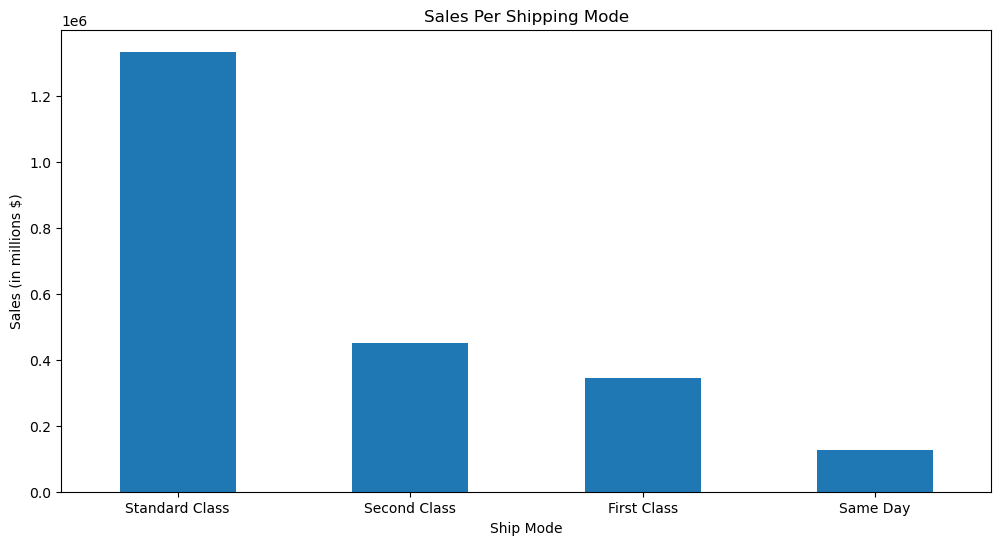

In [99]:
plt.figure(figsize=(12,6))
sales_per_shipping_mode.plot(kind='bar',width=0.5) 
plt.title('Sales Per Shipping Mode')
plt.ylabel('Sales (in millions $)')
plt.xticks(rotation=0)
plt.show()

**Standard Class has both the most orders (5,900) AND the most sales ($1.3M) — consistent. Same Day has the fewest orders AND the lowest sales.**

## What are the monthly sales trends?

In [100]:
df['Month'] = df['Order Date'].dt.month_name()
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_sales = (df.groupby('Month')['Sales'].sum().reindex(month_order))
monthly_sales

Month
January      91,982.14
February     59,371.12
March       197,573.59
April       134,988.25
May         154,086.72
June        145,837.52
July        145,535.69
August      157,315.93
September   300,103.41
October     199,496.29
November    345,041.61
December    321,275.14
Name: Sales, dtype: float64

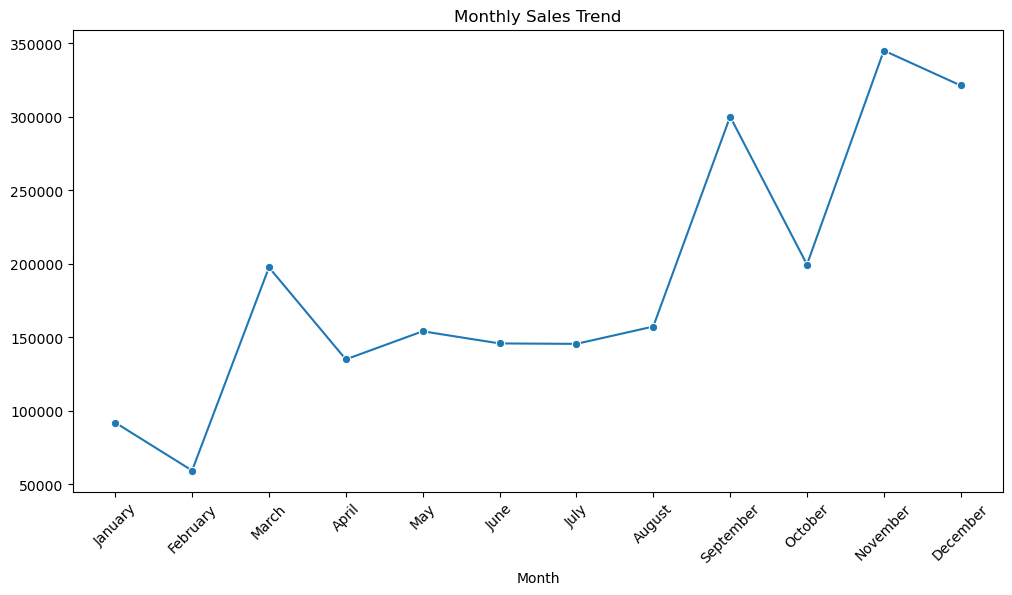

In [101]:
plt.figure(figsize=(12,6))
sns.lineplot(x=monthly_sales.index,y=monthly_sales.values,marker='o')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.show()

**1 — November is the peak month
~$345K — this is clearly Black Friday and holiday shopping driving a massive spike.**

**2 — Strong Q4 overall (September–December)
The second half of the year is dramatically stronger than the first. Q4 alone likely accounts for ~40% of annual sales.**

**3 — February is the worst month
Only ~$65K — the post-holiday slump is very real.**

**4 — The mysterious March spike
~$200K in March stands out as unusual — possibly a promotional campaign or large bulk orders that month.**

## What are the yearly sales trends?

In [102]:
df['Year'] = df['Order Date'].dt.year
yearly_sales = df.groupby('Year')['Sales'].sum()
yearly_sales

Year
2015   479,856.21
2016   454,315.91
2017   597,225.49
2018   721,209.81
Name: Sales, dtype: float64

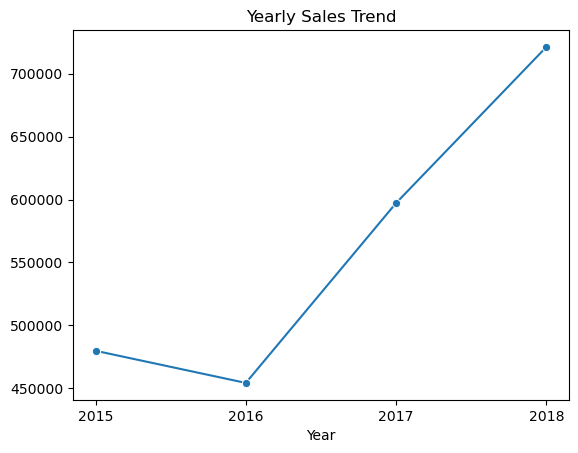

In [103]:
plt.figure()
sns.lineplot(x=yearly_sales.index,y=yearly_sales.values,marker='o')
plt.title('Yearly Sales Trend')
plt.xticks([2015, 2016, 2017, 2018])
plt.show()

**1 — Strong overall growth from 2015 to 2018
Sales grew from ~480K to ~720K — a 50% increase in 3 years. This is a healthy growing business.**

**2 — 2016 was a bad year
The only dip in the trend — sales dropped from 480K to 455K. Worth investigating why — was it a market problem, lost customers, or fewer products?**

**3 — 2017–2018 is explosive growth
From 455K to 720K in just 2 years — the business clearly recovered strongly and accelerated.**


## Which customer segments generate the most sales?

In [104]:
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
segment_sales

Segment
Consumer      1,146,708.15
Corporate       682,211.83
Home Office     423,687.43
Name: Sales, dtype: float64

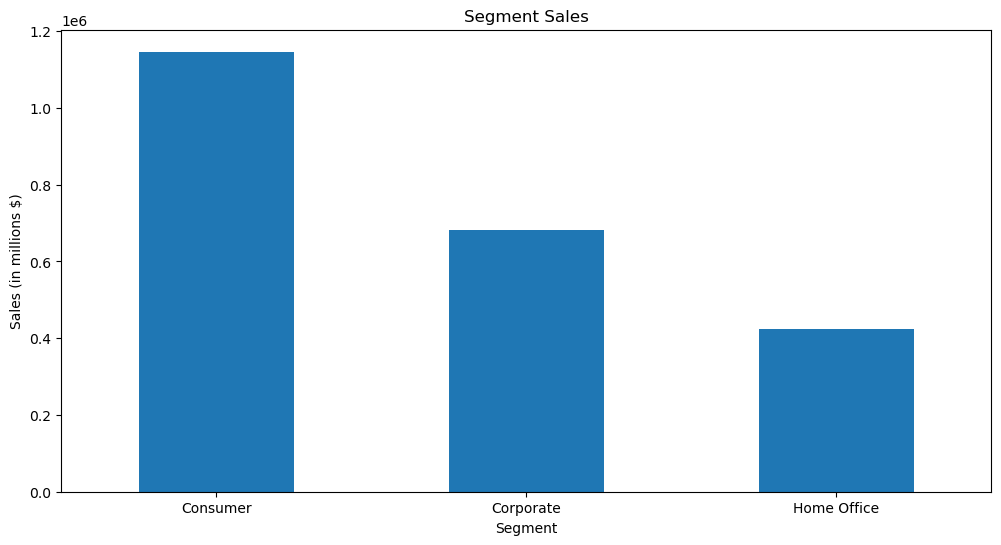

In [105]:
plt.figure(figsize=(12,6))
segment_sales.plot(kind='bar',width=0.5) 
plt.title('Segment Sales')
plt.ylabel('Sales (in millions $)')
plt.xticks(rotation=0)
plt.show()

**1 — Consumer dominates completely
Consumer generates ~$1.15M — nearly double Corporate (~$690K) and almost triple Home Office (~$420K). It is by far the most important segment.**

**2 — Clear three-tier structure
Each segment is roughly 40% smaller than the one above it:**

**- Consumer → Corporate: ~40% drop**

**-Corporate → Home Office: ~39% drop**

## What is the average order value?

In [106]:
average_order_value = df['Sales'].mean()
print('The average order value is',average_order_value)

The average order value is 230.1161929410563


**Average Order Value (AOV) measures the average amount spent per order.**

**It is a key performance indicator used to evaluate customer purchasing behavior.**

## Is there a relationship between shipping days and sales?

In [107]:
corr_matrix=df[['Shipping_Days','Sales']].corr()
corr_matrix

,Shipping_Days,Sales
Shipping_Days,1.00,-0.01
Sales,-0.01,1.00


**It is essentially zero — there is virtually no linear relationship between shipping days and sales amount. Whether an order takes 1 day or 7 days to ship has absolutely no connection to how much money was spent.**

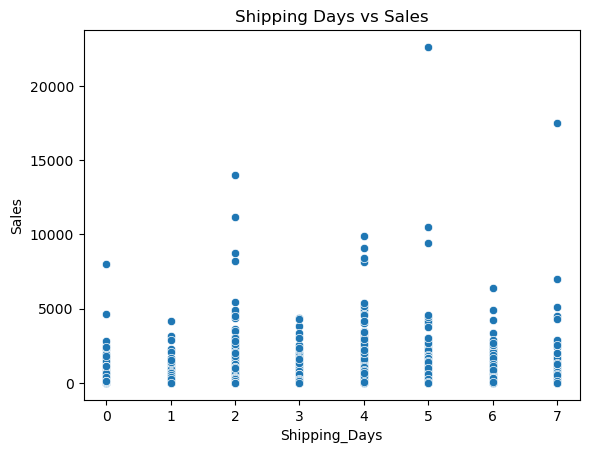

In [108]:
plt.figure()
sns.scatterplot(x=df['Shipping_Days'],y=df['Sales'])
plt.title('Shipping Days vs Sales')
plt.show()

**Look at any vertical column of dots — for example day 4:**

**Some orders cost ~100
Some cost ~5,000
Some cost ~9,000**

**The dots are spread randomly from top to bottom for every single shipping day. There is no diagonal trend going up or down — which is exactly what a correlation of -0.01 looks like visually.**

# Executive Summary

This project analyzed a retail sales dataset to identify the main drivers of business performance across products, customers, regions, shipping methods, and customer segments.

The analysis focused on understanding revenue distribution, customer purchasing behavior, seasonal trends, and operational performance. Several business questions were explored to determine which products, locations, and customer groups contribute most to overall sales.

The findings provide valuable insights that can help management optimize resource allocation, improve customer retention strategies, and support future business growth through data-driven decision making.

# Conclusions

The analysis revealed several important business insights.

Technology was the highest-performing category, although all three product categories contributed significantly to overall revenue. Phones and Chairs emerged as the strongest sub-categories, generating substantially more sales than most other products.

The West and East regions were responsible for the majority of total sales, while California clearly dominated all states in revenue generation. Customer analysis showed that a relatively small number of customers contributed disproportionately to total sales, highlighting the importance of customer retention.

Standard Class was both the most frequently used shipping method and the largest contributor to sales, indicating that customers generally prioritize cost-effective shipping options over speed.

Sales trends showed strong seasonality, with November generating the highest sales volume, likely driven by holiday shopping and promotional events. Additionally, the business demonstrated healthy long-term growth, with sales increasing significantly between 2015 and 2018.

The Consumer segment generated the largest share of revenue, making it the most important customer group. Finally, shipping time showed virtually no relationship with sales value, suggesting that order size is largely independent of delivery speed.

# Recommendations

Based on the analysis, several actions could help improve business performance.

The company should continue investing in high-performing categories such as Technology while maintaining strong inventory levels for top-selling products like Phones and Chairs.

Marketing efforts should focus on the Consumer segment, which generates the largest share of revenue. Additionally, customer retention programs should target high-value customers, as a relatively small group contributes significantly to overall sales.

The company should further strengthen its presence in high-performing regions such as the West and East while investigating opportunities to improve performance in weaker markets.

Given the strong seasonal sales peak observed in November, management should prepare inventory, staffing, and promotional campaigns well in advance to maximize revenue during high-demand periods.

Since Standard Class is both the most popular and highest-revenue shipping option, the company should continue optimizing this service while carefully evaluating the profitability of premium shipping alternatives.

Finally, management should regularly monitor sales trends and customer behavior to support data-driven strategic decisions and sustain long-term business growth.